# Actividad 3 — EDA · NASA POWER

**Objetivo:** Analizar las 8 variables climaticas, identificar variables redundantes mediante correlacion, y justificar cuales son mas relevantes para predecir la produccion de limon.

**Entrada:** `pipeline/output/02_lectura/nasa_long_raw.csv`
**Salidas:** Graficos en `pipeline/output/03_eda/act03_nasa_*.png`


## Configuracion inicial


In [1]:
import os, sys, json, glob, warnings, unicodedata
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

while not os.path.exists('pipeline/config/pipeline_config.json'):
    os.chdir('..')
with open('pipeline/config/pipeline_config.json','r',encoding='utf-8') as f:
    CONFIG = json.load(f)
SOURCES = CONFIG['sources']
OUTPUT  = CONFIG['output']
print('Config cargado OK | Raiz:', os.getcwd())


Config cargado OK | Raiz: C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-


## Carga de datos NASA


In [2]:
df_nasa = pd.read_csv(OUTPUT['lectura'] + 'nasa_long_raw.csv', low_memory=False)
VARS_CLIMA = [c for c in df_nasa.columns
              if c not in ['DEPARTAMENTO','PROVINCIA','YEAR','MES']]
print(f'Shape: {df_nasa.shape}')
print(f'Variables climaticas: {VARS_CLIMA}')
print(f'Departamentos: {df_nasa["DEPARTAMENTO"].nunique()}')
print(f'Provincias: {df_nasa["PROVINCIA"].nunique()}')
print()
print('Estadisticas descriptivas:')
print(df_nasa[VARS_CLIMA].describe().round(3).to_string())


Shape: (6120, 12)
Variables climaticas: ['ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'QV2M', 'RH2M', 'T2M', 'T2M_MAX', 'T2M_MIN', 'WS2M']
Departamentos: 23
Provincias: 102

Estadisticas descriptivas:
       ALLSKY_SFC_SW_DWN  PRECTOTCORR      QV2M      RH2M       T2M   T2M_MAX   T2M_MIN      WS2M
count           6018.000     6120.000  6120.000  6120.000  6120.000  6120.000  6120.000  6120.000
mean              17.854        1.826    11.518    72.136    18.347    26.952    11.688     1.630
std                3.071        2.486     3.586    11.761     6.571     6.013     7.686     1.161
min                9.220        0.000     1.840    22.690     3.420    13.390    -5.930     0.010
25%               15.650        0.230     8.980    65.618    12.690    22.127     4.760     0.210
50%               17.330        0.890    11.170    72.985    19.065    27.400    13.025     1.790
75%               19.468        2.460    13.780    80.030    24.092    31.100    18.020     2.350
max               30.860

## 3.1 Grafico 1 — Distribuciones de las 8 variables climaticas


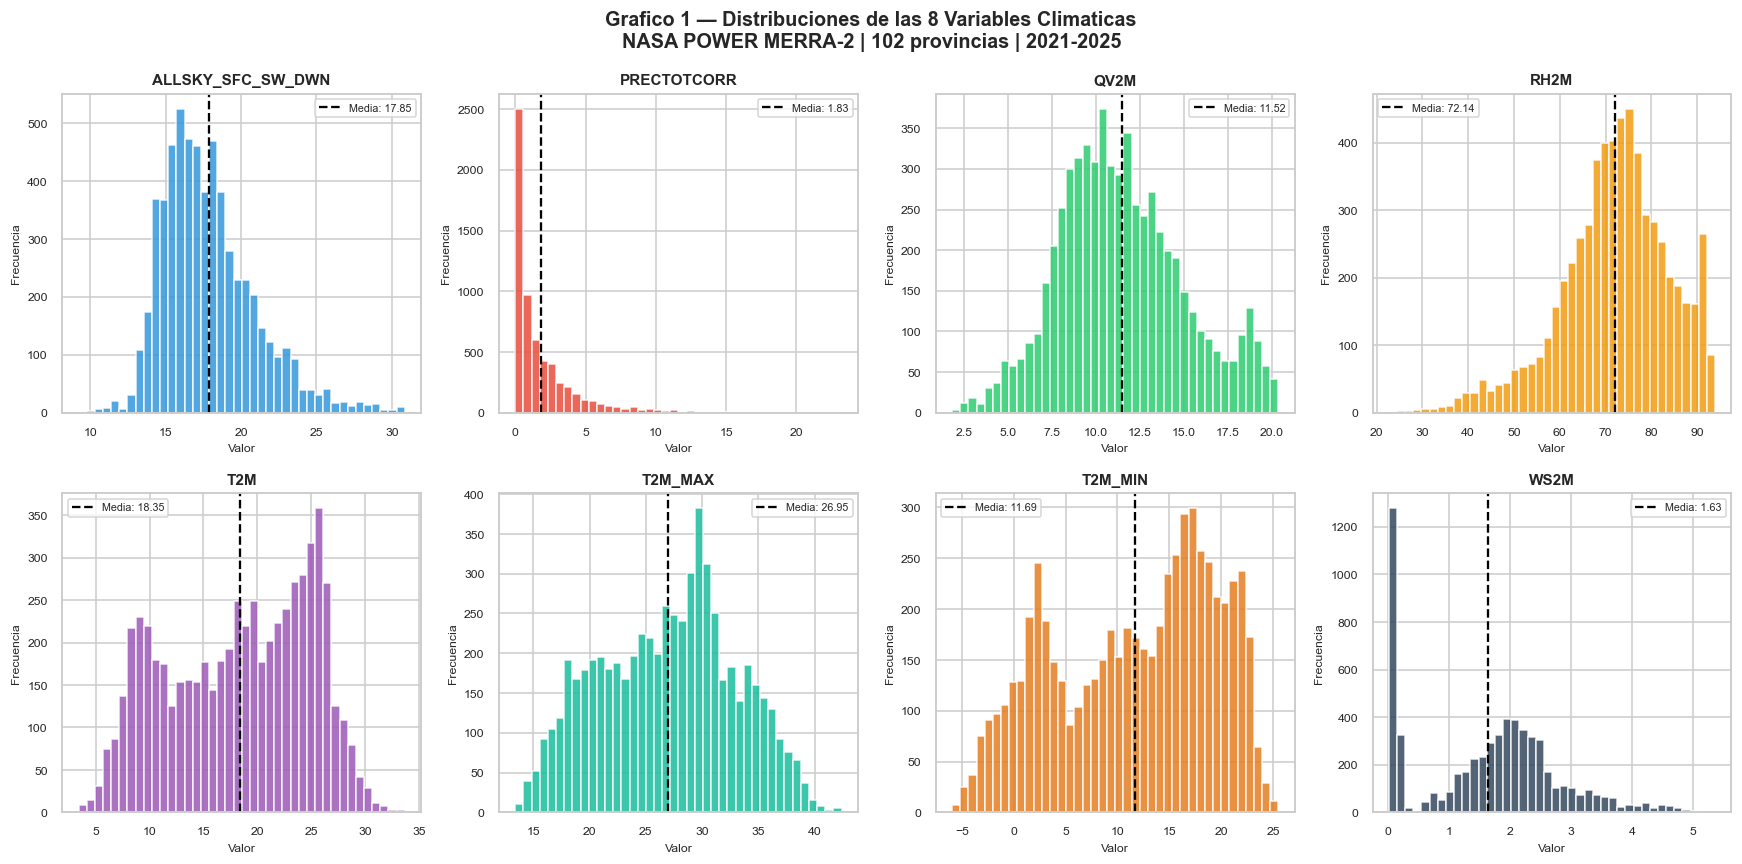

Guardado: pipeline/output/03_eda/act03_nasa_g1_distribuciones.png


In [3]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
colores_hist = ['#3498db','#e74c3c','#2ecc71','#f39c12',
                '#9b59b6','#1abc9c','#e67e22','#34495e']

for i, (var, color) in enumerate(zip(VARS_CLIMA, colores_hist)):
    data = df_nasa[var].dropna()
    axes[i].hist(data, bins=40, color=color, edgecolor='white', alpha=0.85)
    axes[i].axvline(data.mean(), color='black', linestyle='--', linewidth=1.5,
                    label=f'Media: {data.mean():.2f}')
    axes[i].set_title(var, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Valor', fontsize=8)
    axes[i].set_ylabel('Frecuencia', fontsize=8)
    axes[i].legend(fontsize=7)
    axes[i].tick_params(labelsize=8)

plt.suptitle('Grafico 1 — Distribuciones de las 8 Variables Climaticas\n'
             'NASA POWER MERRA-2 | 102 provincias | 2021-2025',
             fontsize=13, fontweight='bold')
plt.tight_layout()
g = OUTPUT['eda'] + 'act03_nasa_g1_distribuciones.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Interpretacion

**Que muestra:** La distribucion de cada variable climatica en las 102 provincias. Distribuciones bimodales indican que hay dos grupos de provincias con climas muy diferentes (costa vs. sierra, por ejemplo).

**Implicacion para el pipeline:** Variables con distribuciones muy sesgadas pueden requerir transformacion logaritmica antes del escalado en la Actividad 9. PRECTOTCORR tipicamente tiene distribucion muy sesgada (muchas provincias con poca lluvia).

**Implicacion para el modelo:** El StandardScaler que se aplicara en la Actividad 9 asume distribuciones aproximadamente normales. Variables muy sesgadas pueden degradar el rendimiento del LSTM-Attention si no se transforman previamente.


## 3.2 Grafico 2 — Series temporales climaticas para provincias clave


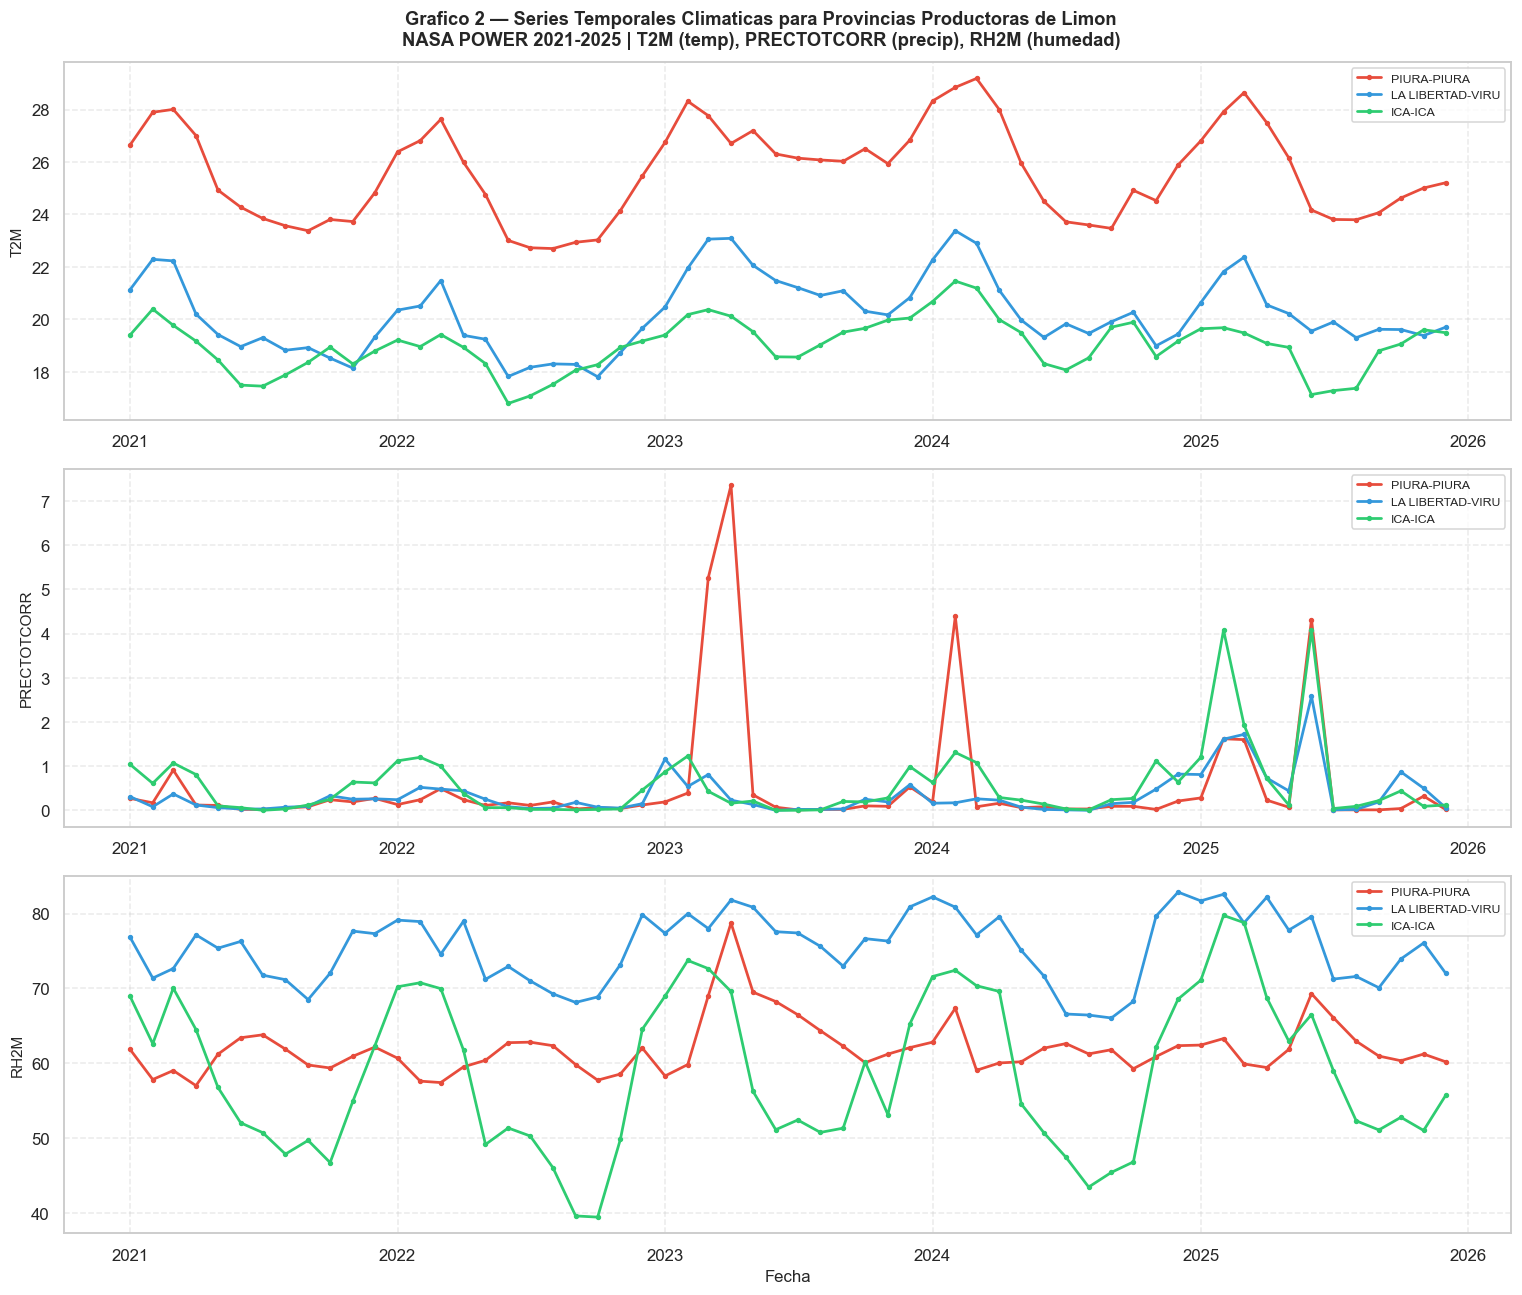

Guardado: pipeline/output/03_eda/act03_nasa_g2_series.png


In [4]:
provincias_clave = [('PIURA','PIURA'), ('LA LIBERTAD','VIRU'), ('ICA','ICA')]
vars_plot = ['T2M', 'PRECTOTCORR', 'RH2M']
colores_prov = ['#e74c3c','#3498db','#2ecc71']
meses_nombres = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, axes = plt.subplots(len(vars_plot), 1, figsize=(14, 12))

for ax, var in zip(axes, vars_plot):
    for (dpto, prov), color in zip(provincias_clave, colores_prov):
        mask = ((df_nasa['DEPARTAMENTO'].str.upper() == dpto) &
                (df_nasa['PROVINCIA'].str.upper() == prov))
        df_sub = df_nasa[mask].sort_values(['YEAR','MES']).copy()
        if df_sub.empty or var not in df_sub.columns:
            continue
        df_sub['fecha'] = pd.to_datetime(
            df_sub['YEAR'].astype(str) + '-' + df_sub['MES'].astype(str).str.zfill(2) + '-01'
        )
        ax.plot(df_sub['fecha'], df_sub[var], color=color, linewidth=1.8,
                marker='o', markersize=2.5, label=f'{dpto}-{prov}')
    ax.set_ylabel(var, fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.4)

axes[-1].set_xlabel('Fecha', fontsize=11)
plt.suptitle('Grafico 2 — Series Temporales Climaticas para Provincias Productoras de Limon\n'
             'NASA POWER 2021-2025 | T2M (temp), PRECTOTCORR (precip), RH2M (humedad)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['eda'] + 'act03_nasa_g2_series.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Interpretacion

**Que muestra:** La evolucion mensual de temperatura, precipitacion y humedad en las tres principales zonas productoras de limon. El pico de precipitacion en 2023 deberia ser visible si el Nino Costero afecto estas zonas.

**Implicacion para el pipeline:** Las anomalias climaticas visibles en 2023 deben correlacionar con los datos de INDECI (mas emergencias) y MIDAGRI (menos produccion). Esta triangulacion valida la coherencia entre las 3 fuentes.

**Implicacion para el modelo:** La estacionalidad climatica visible confirma que las variables NASA tienen patrones temporales que el LSTM-Attention puede aprender. La diferencia entre provincias (Piura vs Ica) justifica mantener la granularidad provincial.


## 3.3 Grafico 3 — Correlacion entre variables climaticas


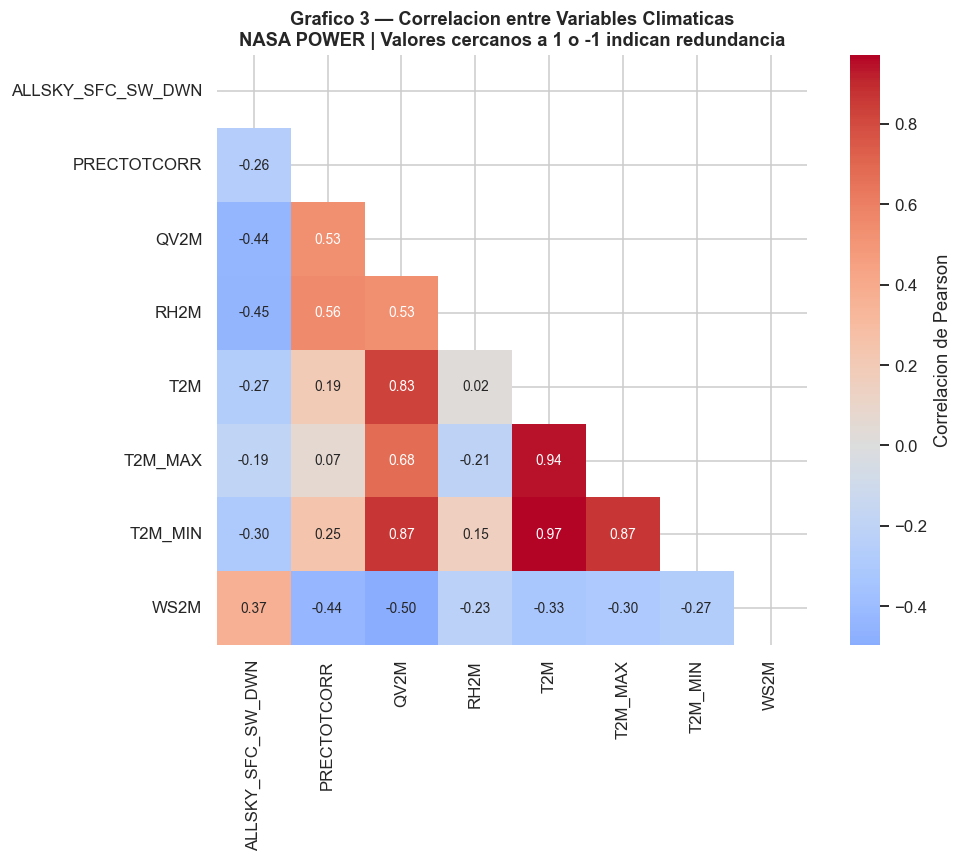

Guardado: pipeline/output/03_eda/act03_nasa_g3_correlacion.png

Pares con alta correlacion (|r| > 0.85):
  QV2M vs T2M_MIN: r = 0.866
  T2M vs T2M_MAX: r = 0.945
  T2M vs T2M_MIN: r = 0.973
  T2M_MAX vs T2M_MIN: r = 0.868


In [5]:
corr_nasa = df_nasa[VARS_CLIMA].corr().round(3)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_nasa, dtype=bool))
sns.heatmap(corr_nasa, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, ax=ax,
            cbar_kws={'label': 'Correlacion de Pearson'},
            annot_kws={'size': 9})
ax.set_title('Grafico 3 — Correlacion entre Variables Climaticas\n'
             'NASA POWER | Valores cercanos a 1 o -1 indican redundancia',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['eda'] + 'act03_nasa_g3_correlacion.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)
print()
print('Pares con alta correlacion (|r| > 0.85):')
for i in range(len(VARS_CLIMA)):
    for j in range(i+1, len(VARS_CLIMA)):
        r = corr_nasa.iloc[i, j]
        if abs(r) > 0.85:
            print(f'  {VARS_CLIMA[i]} vs {VARS_CLIMA[j]}: r = {r:.3f}')


### Interpretacion

**Que muestra:** La correlacion entre las 8 variables climaticas. Pares con |r| > 0.85 son candidatos a redundancia — incluir ambas no aporta informacion adicional al modelo y aumenta la complejidad innecesariamente.

**Implicacion para el pipeline:** Las variables altamente correlacionadas (ej. T2M vs T2M_MAX, QV2M vs RH2M) se evaluaran para posible descarte en la Actividad 9. Se conservara la que tenga mayor correlacion con la produccion de limon.

**Implicacion para el modelo:** Incluir variables redundantes no mejora la prediccion pero si aumenta el tiempo de entrenamiento y el riesgo de sobreajuste. La seleccion de variables es critica para un LSTM eficiente.


## 3.4 Grafico 4 — Correlacion clima vs. produccion de limon


Meses en comun clima-produccion: 56


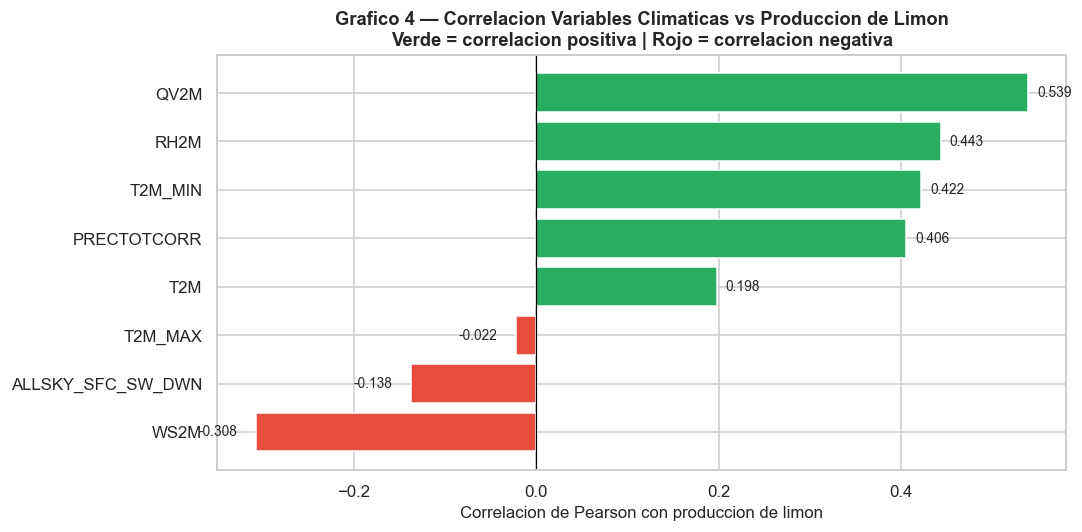

Guardado: pipeline/output/03_eda/act03_nasa_g4_vs_produccion.png

Variable mas correlacionada con produccion: QV2M
Correlacion: 0.539


In [6]:
# Construir dataset mensual con clima + produccion
xl = pd.ExcelFile(SOURCES['midagri'])
dfs_m = [pd.read_excel(SOURCES['midagri'], sheet_name=s) for s in xl.sheet_names]
df_m = pd.concat(dfs_m, ignore_index=True)
df_limon = df_m[df_m['dsc_Cultivo'].str.upper().str.contains('LIMON', na=False)].copy()
prod_mensual = df_limon.groupby(['anho','mes'])['PRODUCCION(t)'].sum().reset_index()
prod_mensual.columns = ['YEAR','MES','produccion_t']

# Agregar clima a nivel nacional (media de todas las provincias)
clima_nacional = df_nasa.groupby(['YEAR','MES'])[VARS_CLIMA].mean().reset_index()

df_merge = pd.merge(clima_nacional, prod_mensual, on=['YEAR','MES'], how='inner')
print(f'Meses en comun clima-produccion: {len(df_merge)}')

if len(df_merge) > 5:
    corr_prod = df_merge[VARS_CLIMA + ['produccion_t']].corr()['produccion_t'].drop('produccion_t')
    corr_prod = corr_prod.sort_values()

    fig, ax = plt.subplots(figsize=(10, 5))
    colors_corr = ['#e74c3c' if v < 0 else '#27ae60' for v in corr_prod.values]
    bars = ax.barh(corr_prod.index, corr_prod.values, color=colors_corr, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    for bar, val in zip(bars, corr_prod.values):
        offset = -0.02 if val < 0 else 0.01
        ax.text(val + offset, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9,
                ha='right' if val < 0 else 'left')
    ax.set_xlabel('Correlacion de Pearson con produccion de limon', fontsize=11)
    ax.set_title('Grafico 4 — Correlacion Variables Climaticas vs Produccion de Limon\n'
                 'Verde = correlacion positiva | Rojo = correlacion negativa',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    g = OUTPUT['eda'] + 'act03_nasa_g4_vs_produccion.png'
    plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
    print('Guardado:', g)
    print()
    print('Variable mas correlacionada con produccion:', corr_prod.abs().idxmax())
    print('Correlacion:', corr_prod.abs().max().round(3))


### Interpretacion

**Que muestra:** La correlacion de cada variable climatica con la produccion mensual de limon. Las variables con mayor correlacion absoluta son las mas informativas para el modelo.

**Implicacion para el pipeline:** Las variables con correlacion cercana a 0 son candidatas a descarte en la Actividad 9. Las variables con correlacion negativa fuerte (ej. precipitacion excesiva reduce produccion) son especialmente valiosas como variables exogenas.

**Implicacion para el modelo:** Este grafico es la justificacion cuantitativa para incluir las variables NASA en el LSTM-Attention. Variables con |r| > 0.3 tienen poder predictivo estadisticamente significativo.


## 3.5 Grafico 5 — Estacionalidad climatica


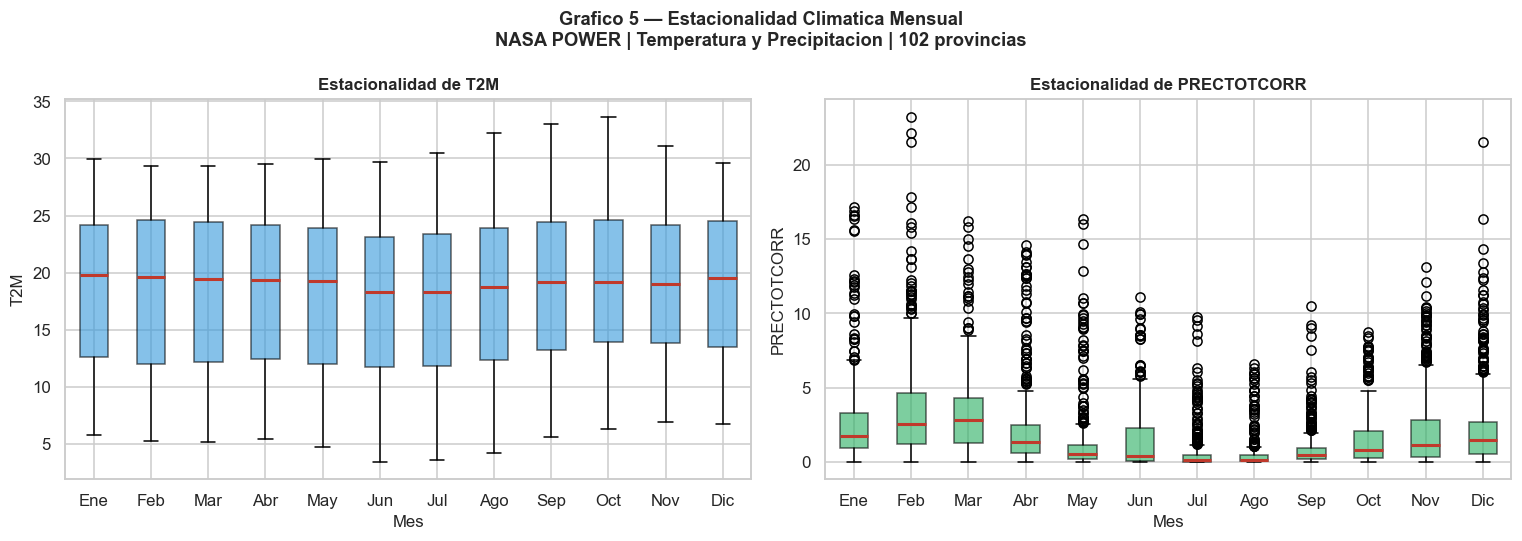

Guardado: pipeline/output/03_eda/act03_nasa_g5_estacionalidad.png


In [7]:
vars_estac = ['T2M', 'PRECTOTCORR']
meses_nombres = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, var in zip(axes, vars_estac):
    data_mes = [df_nasa[df_nasa['MES']==m][var].dropna().values for m in range(1,13)]
    bp = ax.boxplot(data_mes, labels=meses_nombres, patch_artist=True,
                    medianprops=dict(color='#c0392b', linewidth=2))
    color_box = '#3498db' if var == 'T2M' else '#27ae60'
    for patch in bp['boxes']:
        patch.set_facecolor(color_box)
        patch.set_alpha(0.6)
    ax.set_xlabel('Mes', fontsize=11)
    ax.set_ylabel(var, fontsize=11)
    ax.set_title(f'Estacionalidad de {var}', fontsize=11, fontweight='bold')

plt.suptitle('Grafico 5 — Estacionalidad Climatica Mensual\n'
             'NASA POWER | Temperatura y Precipitacion | 102 provincias',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['eda'] + 'act03_nasa_g5_estacionalidad.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Interpretacion

**Que muestra:** La distribucion de temperatura y precipitacion para cada mes del año, agregando todas las provincias. Confirma el patron estacional del clima peruano.

**Implicacion para el pipeline:** La estacionalidad clara en ambas variables justifica la codificacion ciclica (month_sin/cos) que se aplicara en la Fase 2. Sin esta codificacion, el modelo no sabria que enero y diciembre son meses consecutivos.

**Implicacion para el modelo:** El LSTM-Attention puede aprender la estacionalidad de la secuencia temporal, pero la codificacion ciclica explicita acelera el aprendizaje y mejora la generalizacion a periodos no vistos durante el entrenamiento.


In [8]:
print('[ACTIVIDAD 3 - NASA] COMPLETADA.')
print('Siguiente: pipeline/fuentes/agraria-pe/actividad_03_eda_agraria.ipynb')


[ACTIVIDAD 3 - NASA] COMPLETADA.
Siguiente: pipeline/fuentes/agraria-pe/actividad_03_eda_agraria.ipynb
